# 1NN vs RandomForest

Сравним ближайшего соседа и случайный лес на распознавании рукописных цифр, изучим accuracy, матрицы ошибок и примеры неверных прогнозов.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

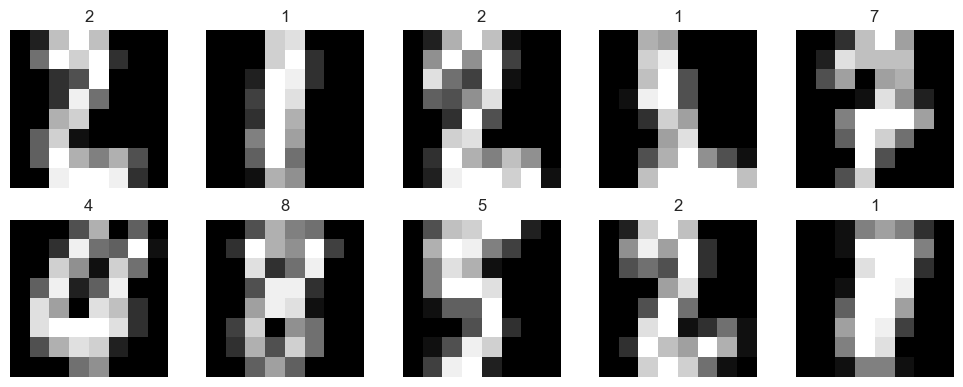

In [2]:
digits = load_digits()
features = digits.data
target = digits.target
train_features, test_features, train_target, test_target, train_images, test_images = train_test_split(
    features, target, digits.images, test_size=0.25, random_state=42, stratify=target
)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for axis, image, label in zip(axes.ravel(), train_images[:10], train_target[:10]):
    axis.imshow(image, cmap="gray")
    axis.set_title(str(label))
    axis.axis("off")
plt.tight_layout()
plt.show()

In [3]:
models = {
    "1NN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=1)),
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=1, random_state=42),
}
predictions = {}
rows = []
for name, model in models.items():
    model.fit(train_features, train_target)
    prediction = model.predict(test_features)
    predictions[name] = prediction
    rows.append({"model": name, "accuracy": accuracy_score(test_target, prediction)})

pd.DataFrame(rows).set_index("model")

,accuracy
model,
1NN,0.971111
Random Forest,0.968889


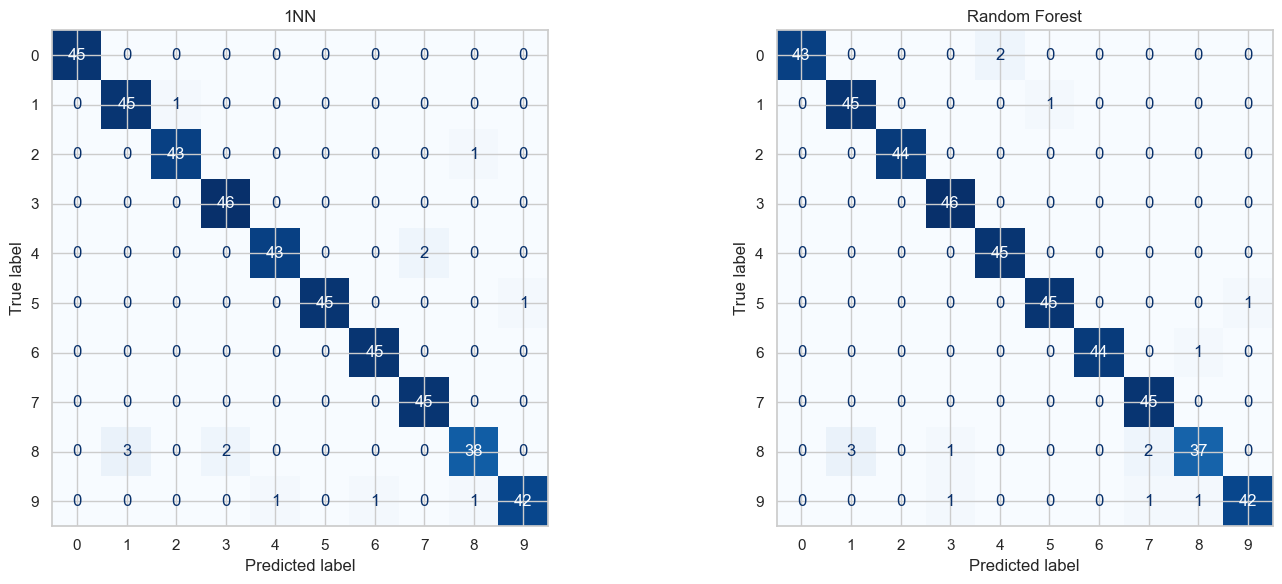

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, (name, prediction) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(test_target, prediction, ax=axis, cmap="Blues", colorbar=False)
    axis.set_title(name)
plt.tight_layout()
plt.show()

## Ошибки Random Forest

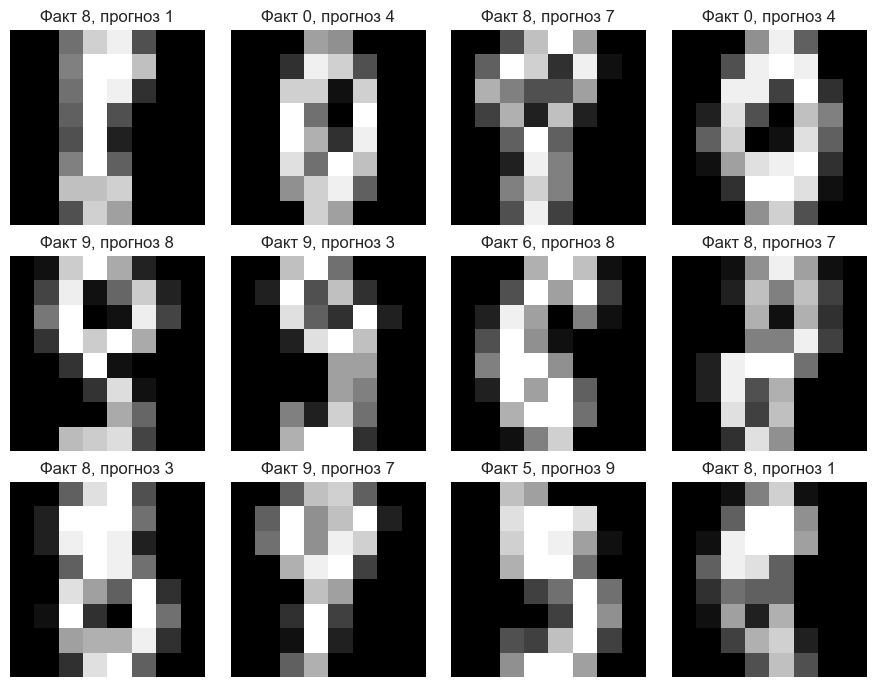

In [5]:
forest_prediction = predictions["Random Forest"]
error_indices = np.flatnonzero(forest_prediction != test_target)[:12]

fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for axis, index in zip(axes.ravel(), error_indices):
    axis.imshow(test_images[index], cmap="gray")
    axis.set_title(f"Факт {test_target[index]}, прогноз {forest_prediction[index]}")
    axis.axis("off")
plt.tight_layout()
plt.show()

## Вывод

1NN хранит обучающую выборку и чувствителен к масштабу признаков. Random Forest строит ансамбль деревьев, лучше сглаживает шум и обычно устойчивее на многомерных данных.